# GRU实验
韩佳轩，23281106，计算机科学与技术学院

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt

# 导入数据集和工具函数
from datasets import TrafficDataset, my_Dataset
from utils import train, test, visualize, plot_metric

In [2]:
torch.manual_seed(23281106)

## 手动实现GRU

In [3]:
class My_GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.gates = nn.Linear(input_size+hidden_size, hidden_size*2)
        # 用于计算candidate hidden state
        self.hidden_transform = nn.Linear(input_size+hidden_size, hidden_size)
        
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        
        self.output = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size)
        )
            
        for param in self.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)
                
    def forward(self, x):
        batch_size = x.size(0)
        seq_len = x.size(1)
        
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        y_list = []
        for i in range(seq_len):
            update_gate, reset_gate = self.gates(torch.cat([x[:, i, :], h], dim=-1)).chunk(2, -1)
            update_gate, reset_gate = (self.sigmoid(gate) for gate in (update_gate, reset_gate))
            candidate_hidden = self.tanh(self.hidden_transform(torch.cat([x[:, i, :], reset_gate * h], dim=-1)))
            h = (1-update_gate) * h + update_gate * candidate_hidden
            y_list.append(self.output(h))
        return torch.stack(y_list, dim=1), h

In [4]:
# 超参数设置
sensor = 171
window_size = 12
target = 'pm25'
batch_size = 64
hidden_size = 64
learning_rate = 0.001
num_epoch = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# 数据加载,使用TrafficDataset
print("Loading dataset...")
dataset = TrafficDataset(sensor=96)
train_set, val_set, test_set = dataset.construct_set(
        train_por=0.6, test_por=0.2, window_size=window_size
    )
    
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)
    
input_size = train_set.X.shape[-1] 
print(f"Input size: {input_size}, Samples: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

Loading dataset...
Input size: 3, Samples: train=10701, val=3559, test=3560


d:\Programming&Labs\DeepLearning\Lab5\datasets.py:137: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  train_set = my_Dataset(torch.Tensor(train_x), torch.Tensor(train_y))


In [6]:
# 模型、损失、优化器
model = My_GRU(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
# 反标准化函数（用于评估真实物理量）
def denormalize_fn(x):
    return dataset.denormalize(x.squeeze(-1))

In [7]:
# 训练
print("Start training MyGRU...")
start_time = time.time()
    
train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
        net=model,
        train_iter=train_loader,
        val_iter=val_loader,
        test_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        optimizer=optimizer,
        num_epoch=num_epoch,
        early_stop=10,
        device=device,
        output_model=None, 
        is_print=True,
        is_print_batch=False
    )
    
total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.2f}s")

# 测试集最终评估
test_score, test_loss = test(
        net=model,
        output_model=None,
        data_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        device=device
    )
print("Final Test Result:")
print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

Start training MyGRU...
*** epoch1, train loss 0.0012, train rmse 32.2161, val loss 0.0004, val rmse 21.621673, time use 4.394s
*** epoch2, train loss 0.0004, train rmse 22.1186, val loss 0.0004, val rmse 21.291961, time use 3.565s
*** epoch3, train loss 0.0004, train rmse 21.9806, val loss 0.0004, val rmse 21.436555, time use 4.773s
*** epoch4, train loss 0.0004, train rmse 22.2960, val loss 0.0003, val rmse 20.377107, time use 6.179s
*** epoch5, train loss 0.0004, train rmse 21.7015, val loss 0.0004, val rmse 20.610338, time use 5.101s
*** epoch6, train loss 0.0004, train rmse 22.1066, val loss 0.0004, val rmse 21.850031, time use 3.854s
*** epoch7, train loss 0.0004, train rmse 21.6785, val loss 0.0004, val rmse 22.108508, time use 4.035s
*** epoch8, train loss 0.0004, train rmse 21.9772, val loss 0.0003, val rmse 20.285541, time use 4.166s
*** epoch9, train loss 0.0004, train rmse 22.1181, val loss 0.0004, val rmse 20.999732, time use 4.971s
*** epoch10, train loss 0.0004, train rm

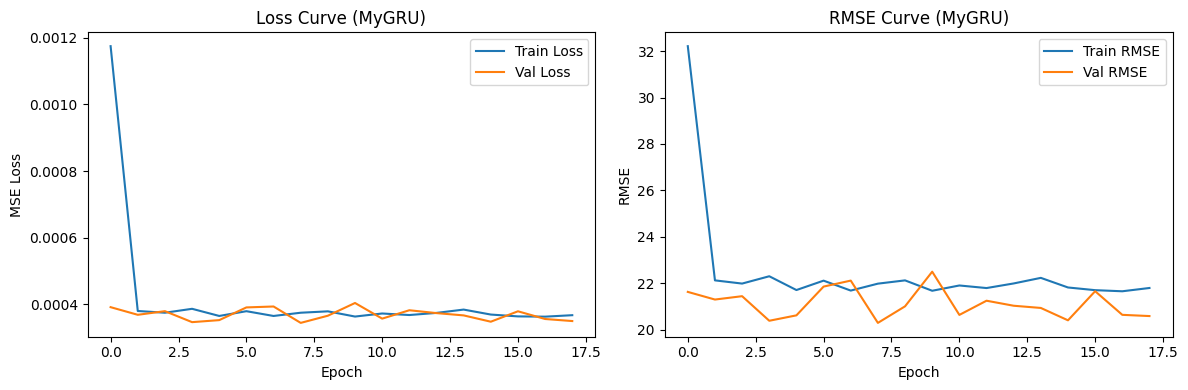

In [8]:
# 可视化
plt.figure(figsize=(12, 4))
    
plt.subplot(1, 2, 1)
plt.plot(train_loss_lst, label='Train Loss')
plt.plot(val_loss_lst, label='Val Loss')
plt.title('Loss Curve (MyGRU)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
    
plt.subplot(1, 2, 2)
score_array = np.array(train_score_lst)
plt.plot(score_array[:, 0], label='Train RMSE')
val_score_array = np.array(val_score_lst)
plt.plot(val_score_array[:, 0], label='Val RMSE')
plt.title('RMSE Curve (MyGRU)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.savefig('MyGRU_training_curve.png')
plt.show()

## Torch.nn实现GRU

In [9]:
# Torch内置GRU实现
class TorchGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=1):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.output(out), None  # 返回out和dummy hidden

In [10]:
# 模型、损失、优化器
model_Torch = TorchGRU(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_Torch.parameters(), lr=learning_rate)

In [11]:
# 训练
print("Start training TorchGRU...")
start_time = time.time()
    
train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
        net=model_Torch,
        train_iter=train_loader,
        val_iter=val_loader,
        test_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        optimizer=optimizer,
        num_epoch=num_epoch,
        early_stop=10,
        device=device,
        output_model=None,          # 直接使用LSTM每一步的输出（最后一层已包含output_layer）
        is_print=True,
        is_print_batch=False
    )
    
total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.2f}s")

# 测试集最终评估
test_score, test_loss = test(
        net=model_Torch,
        output_model=None,
        data_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        device=device
    )
print("Final Test Result:")
print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

Start training TorchGRU...
*** epoch1, train loss 0.0014, train rmse 38.1879, val loss 0.0005, val rmse 25.073011, time use 0.657s
*** epoch2, train loss 0.0004, train rmse 22.6300, val loss 0.0004, val rmse 22.966354, time use 0.601s
*** epoch3, train loss 0.0004, train rmse 21.9784, val loss 0.0004, val rmse 20.690073, time use 0.594s
*** epoch4, train loss 0.0004, train rmse 22.2192, val loss 0.0004, val rmse 20.688212, time use 0.631s
*** epoch5, train loss 0.0004, train rmse 22.0397, val loss 0.0004, val rmse 20.854431, time use 0.586s
*** epoch6, train loss 0.0004, train rmse 21.8515, val loss 0.0003, val rmse 20.420025, time use 0.602s
*** epoch7, train loss 0.0004, train rmse 21.9721, val loss 0.0003, val rmse 20.480607, time use 0.583s
*** epoch8, train loss 0.0004, train rmse 21.9725, val loss 0.0004, val rmse 22.097541, time use 0.599s
*** epoch9, train loss 0.0004, train rmse 22.0621, val loss 0.0003, val rmse 20.345511, time use 0.615s
*** epoch10, train loss 0.0004, train

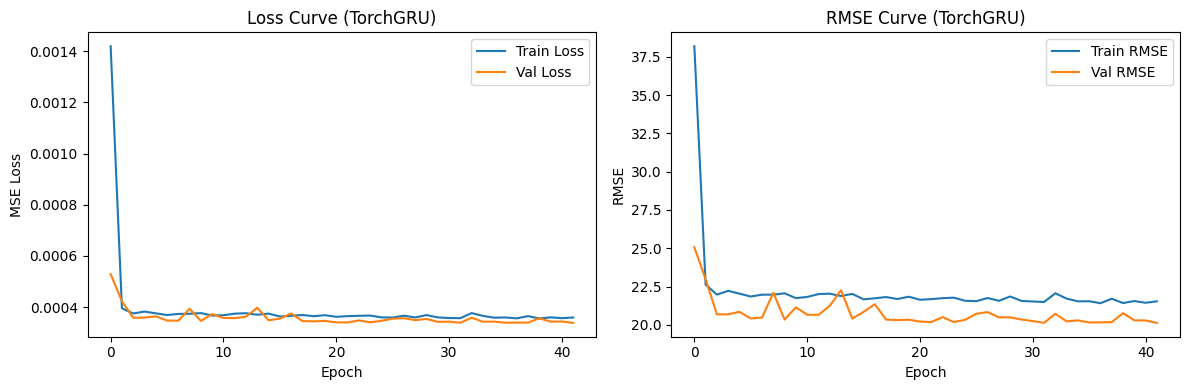

In [12]:
# 可视化
plt.figure(figsize=(12, 4))
    
plt.subplot(1, 2, 1)
plt.plot(train_loss_lst, label='Train Loss')
plt.plot(val_loss_lst, label='Val Loss')
plt.title('Loss Curve (TorchGRU)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
    
plt.subplot(1, 2, 2)
score_array = np.array(train_score_lst)
plt.plot(score_array[:, 0], label='Train RMSE')
val_score_array = np.array(val_score_lst)
plt.plot(val_score_array[:, 0], label='Val RMSE')
plt.title('RMSE Curve (TorchGRU)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.savefig('TorchGRU_training_curve.png')
plt.show()